In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
df = pd.read_csv('../../01_data/processed/model_df.csv')
df.head()

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome,tenure_days
0,32,Montana,Free,Yearly,2,Paypal,Medium,22.391362,1.756575,0.176873,169,109,18,32,52,35,46,0,47631.156827,1606
1,64,New Jersey,Free,Monthly,3,Paypal,Low,29.294210,0.875019,0.981811,55,55,44,33,12,25,37,1,76533.296517,2897
2,51,Washington,Premium,Yearly,2,Credit Card,High,15.400312,0.411728,0.048411,244,117,20,129,50,28,38,0,64452.058299,348
3,63,California,Family,Yearly,4,Apple Pay,Medium,22.842084,1.393258,0.035691,442,252,47,120,55,17,24,0,67180.181705,2894
4,54,Washington,Family,Monthly,3,Paypal,High,23.151163,0.876304,0.039738,243,230,41,66,40,32,47,0,64452.058299,92


In [12]:
df['engagement_score'] = df['weekly_hours'] * df['weekly_unique_songs']
df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,weekly_hours,average_session_length,song_skip_rate,...,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome,tenure_days,tenure_group,friend_group,engagement_score
0,32,Montana,Free,Yearly,2,Paypal,Medium,22.391362,1.756575,0.176873,...,32,52,35,46,0,47631.156827,1606,"(1462.0, 2190.0]","(-0.001, 50.0]",2440.658412
1,64,New Jersey,Free,Monthly,3,Paypal,Low,29.294210,0.875019,0.981811,...,33,12,25,37,1,76533.296517,2897,"(2190.0, 2922.0]","(-0.001, 50.0]",1611.181560
2,51,Washington,Premium,Yearly,2,Credit Card,High,15.400312,0.411728,0.048411,...,129,50,28,38,0,64452.058299,348,"(0.999, 728.0]","(100.0, 150.0]",1801.836538
3,63,California,Family,Yearly,4,Apple Pay,Medium,22.842084,1.393258,0.035691,...,120,55,17,24,0,67180.181705,2894,"(2190.0, 2922.0]","(100.0, 150.0]",5756.205165
4,54,Washington,Family,Monthly,3,Paypal,High,23.151163,0.876304,0.039738,...,66,40,32,47,0,64452.058299,92,"(0.999, 728.0]","(50.0, 100.0]",5324.767508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,29.161399,0.119612,0.893839,...,199,71,41,41,0,67180.181705,1895,"(1462.0, 2190.0]","(150.0, 199.0]",641.550779
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,44.744198,1.751156,0.668759,...,185,67,23,30,0,49140.932961,2778,"(2190.0, 2922.0]","(150.0, 199.0]",715.907170
124997,45,Maine,Family,Monthly,0,Paypal,Medium,15.200073,1.301067,0.286604,...,40,78,40,28,0,49140.932961,604,"(0.999, 728.0]","(-0.001, 50.0]",167.200807
124998,69,Maine,Free,Monthly,4,Paypal,High,35.270053,0.348684,0.092528,...,41,3,35,9,1,49140.932961,2570,"(2190.0, 2922.0]","(-0.001, 50.0]",3809.165737


In [5]:
df[['tenure_days','num_platform_friends','churned']].describe()

,tenure_days,num_platform_friends,churned
count,125000.000000,125000.000000,125000.000000
mean,1460.678936,99.713240,0.513392
std,844.132871,57.681372,0.499823
min,1.000000,0.000000,0.000000
25%,728.000000,50.000000,0.000000
50%,1462.000000,100.000000,1.000000
75%,2190.000000,150.000000,1.000000
max,2922.000000,199.000000,1.000000


In [13]:
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 설정 필요 시

## 1. 가입 후 경과 일수와 고객 이탈률

가설

- H0 (귀무가설)
가입 후 경과 일수와 고객 이탈 여부 사이에는 유의미한 관계가 없다.

- H1 (대립가설)
가입 후 경과 일수가 짧을수록 고객 이탈 가능성이 높다.

가설 설정 근거

- 서비스 이용 기간이 짧은 사용자일수록 플랫폼에 대한 충성도와 이용 습관이 형성되지 않았을 가능성이 높기 때문에 이탈 가능성이 높을 것으로 예상된다.

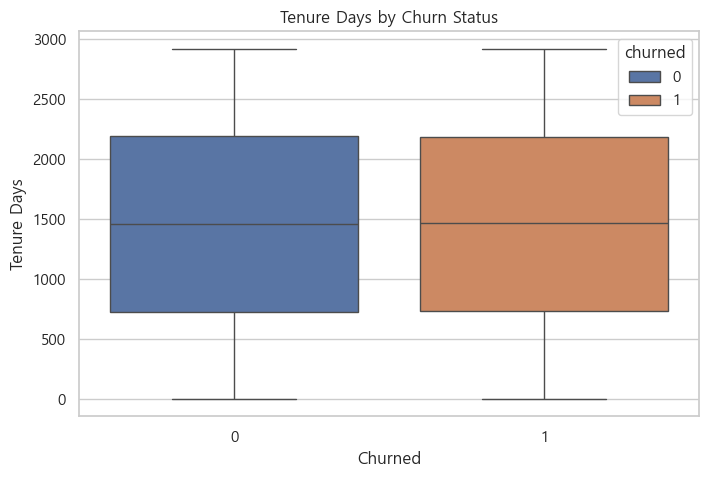

In [15]:
# Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churned',
    y='tenure_days',
    data=df,
    hue = 'churned',
)

plt.title('Tenure Days by Churn Status')
plt.xlabel('Churned')
plt.ylabel('Tenure Days')

plt.show()

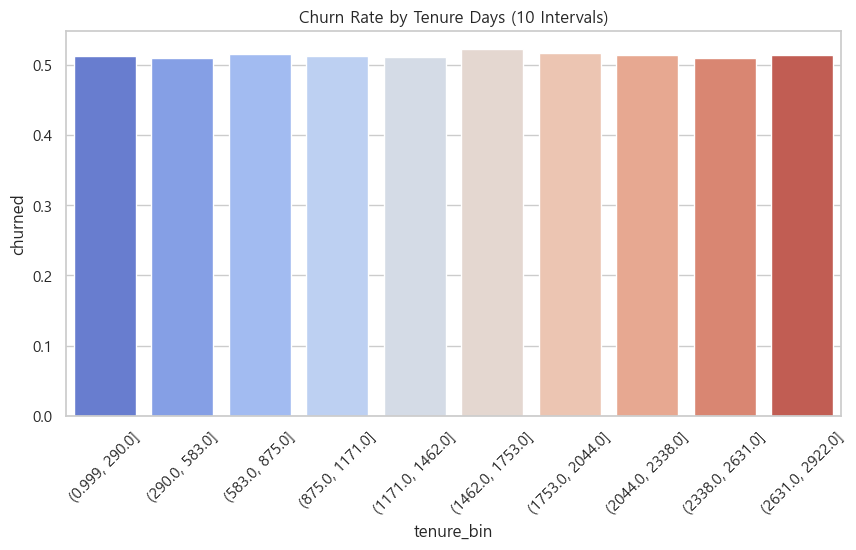

In [23]:
plt.figure(figsize=(10, 5))
df['tenure_bin'] = pd.qcut(df['tenure_days'], 10)

# 수정: observed=False 추가
tenure_churn = df.groupby('tenure_bin', observed=False)['churned'].mean().reset_index()
tenure_churn['tenure_bin'] = tenure_churn['tenure_bin'].astype(str)

# 수정: hue='tenure_bin' 및 legend=False 추가
sns.barplot(x='tenure_bin', y='churned', data=tenure_churn,
            hue='tenure_bin', palette='coolwarm', legend=False)

plt.title('Churn Rate by Tenure Days (10 Intervals)')
plt.xticks(rotation=45)
plt.show()

- 분석 결과: 상관관계가 거의 없음 (0.0012). 가입 기간에 상관없이 이탈률이 약 51%로 일정함.
-> 기각

## 2. 사용자 몰입도 점수와 고객 이탈률

가설

- H0 (귀무가설)
사용자 몰입도 점수와 고객 이탈 여부 사이에는 유의미한 관계가 없다.

- H1 (대립가설)
사용자 몰입도 점수가 낮을수록 고객 이탈 가능성이 높다.

가설 설정 근거

- 사용자 몰입도 점수는 플랫폼 활동량, 콘텐츠 소비 패턴 등을 종합적으로 반영하는 지표로, 몰입도가 낮을수록 서비스에 대한 관심과 사용 빈도가 낮아 이탈 가능성이 높을 것으로 예상된다.

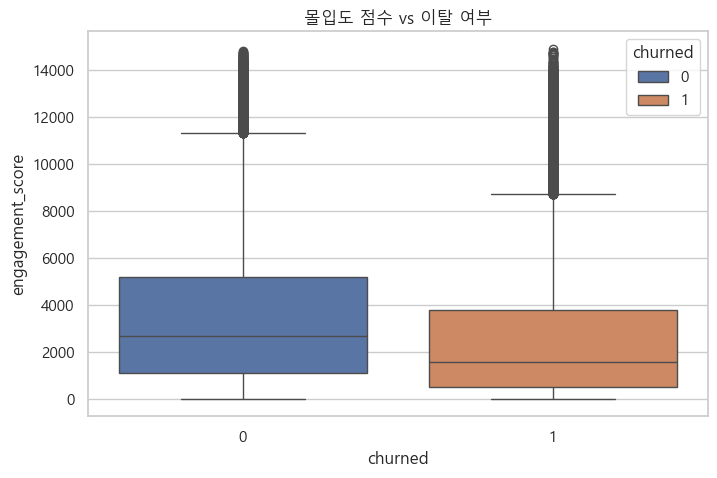

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='churned', y='engagement_score', data=df,hue='churned')
plt.title('몰입도 점수 vs 이탈 여부')
plt.savefig('engagement_vs_churn.png')

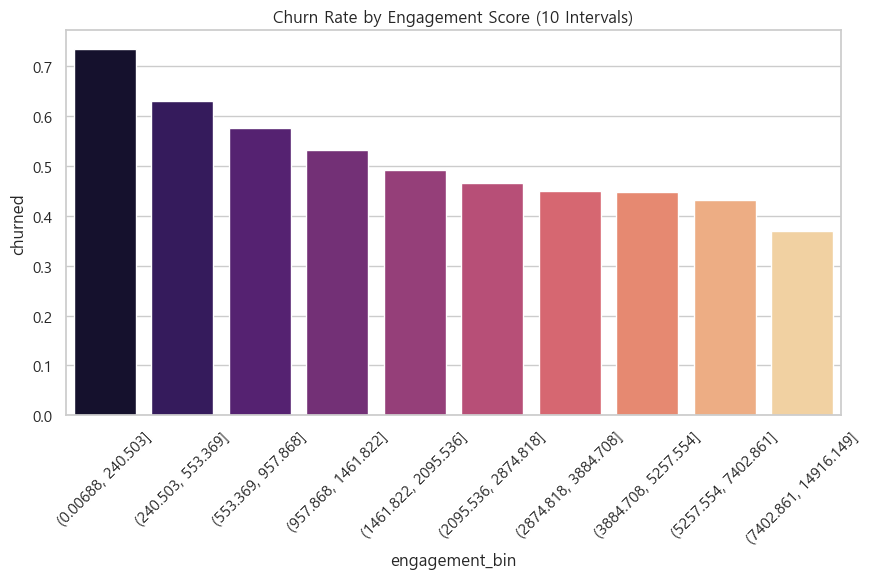

In [24]:
plt.figure(figsize=(10, 5))
df['engagement_bin'] = pd.qcut(df['engagement_score'], 10)

# 수정: observed=False 추가
eng_churn = df.groupby('engagement_bin', observed=False)['churned'].mean().reset_index()
eng_churn['engagement_bin'] = eng_churn['engagement_bin'].astype(str)

# 수정: hue='engagement_bin' 및 legend=False 추가
sns.barplot(x='engagement_bin', y='churned', data=eng_churn,
            hue='engagement_bin', palette='magma', legend=False)

plt.title('Churn Rate by Engagement Score (10 Intervals)')
plt.xticks(rotation=45)
plt.show()

- 분석 결과: 강한 음의 상관관계. 몰입도가 낮을수록 이탈률이 급격히 증가함.

## 3. 고객센터 문의 횟수와 고객 이탈률

가설

- H0 (귀무가설)
고객센터 문의 횟수와 고객 이탈 여부 사이에는 유의미한 관계가 없다.

- H1 (대립가설)
고객센터 문의 횟수가 많을수록 고객 이탈 가능성이 높다.

가설 설정 근거

- 고객센터 문의 횟수는 사용자가 서비스 이용 과정에서 겪는 문제나 불편 사항을 간접적으로 나타내는 지표로 볼 수 있다. 일반적으로 서비스 사용 중 문제가 자주 발생하거나 만족도가 낮은 경우 고객센터 문의가 증가할 가능성이 있다. 이러한 경험이 반복될 경우 서비스에 대한 불만이 누적되어 고객 이탈로 이어질 가능성이 높을 것으로 예상된다.

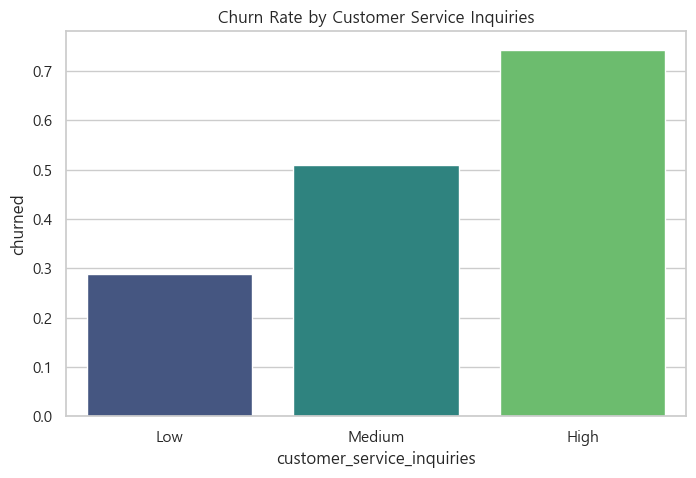

In [25]:
plt.figure(figsize=(8, 5))
inquiry_order = ['Low', 'Medium', 'High']
inquiry_churn = df.groupby('customer_service_inquiries')['churned'].mean().reindex(inquiry_order).reset_index()

# 수정: hue='customer_service_inquiries' 및 legend=False 추가
sns.barplot(x='customer_service_inquiries', y='churned', data=inquiry_churn,
            hue='customer_service_inquiries', palette='viridis', legend=False)

plt.title('Churn Rate by Customer Service Inquiries')
plt.show()

- 분석결과: 가장 강력한 양의 상관관계. 문의가 'High'인 그룹의 이탈률이 'Low' 그룹보다 2.5배 이상 높음.

In [20]:
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['inquiries_num'] = df['customer_service_inquiries'].map(mapping)
print(df[['tenure_days', 'engagement_score', 'inquiries_num', 'churned']].corr()['churned'])

tenure_days         0.001203
engagement_score   -0.171702
inquiries_num       0.371163
churned             1.000000
Name: churned, dtype: float64
